# Calcium Aluminosilicate Glass Simulation with BJP Potential
This notebook is designed to showcase the implementations of the amorphouspy package for simulating multi-component glasses with classical interatomic potentials.
It will be further extended to include more complex simulations and analyses.


## Potential and Elements
Simulations implemented so far are based on the PMMCS interatomic potential from Bouhadja et al., J. Chem. Phys. 138, 224510 (2013), https://doi.org/10.1063/1.4809523.
The PMMCS potential makes use of 2-body Born-Mayer-Huggins interactions between atoms, electrostatic interactions based on scaled partial charges (i.e., O=-1.2, Ca=1.2, Si=2.4, Al=1.8) among all ions, and a repulsive short-range term. 

The supported elements in alphabetical order are:

Si, Al, Ca, O.

Typical compositions the potential can handle include:
- Any composition of the CAS ternary diagram

## Standard Melt-Quenching Protocol and Parameters
Simulation settings employed in the following simulations do not represent production run conditions and are rather for demonstration purposes. They can be adjusted based on the specific requirements of your simulation. The simulation workflow consists of the following steps:

0. Random structure generation based on composition, number of atoms and density. For fast simulations, a small number of atoms (e.g., 200) is used.
1. NVT: heating from 300 to 5000 K with a constant heating rate (here: on the order of 1-10 K/ps)
2. NVT: equilibration of the melt at 5000 K for 100 ps (NVT ensemble)
3. NVT: cooling with down to 300 K (again with 1-10 K/ps)
4. NpT: equilibration at 300 K to relax the stress
5. NVT: extended equilibration at 300 K to extract thermodynamic and structural properties

Typical simulation parameters are applied: lammps metal units, periodic boundary conditions, timestep of 1-2 fs. Other default parameters are hidden in the underlying lammps functions, such as temperature damping of 100 time units and pressure damping of 1000 time units. If desired, Langevin thermostat and barostat can be used by setting the corresponding options.


# Import of packages

In [1]:
from pyiron_base import job, Project


from amorphouspy import (
    melt_quench_simulation as _melt_quench_simulation,
    generate_potential as _generate_potential,
    get_ase_structure as _get_ase_structure,
    get_structure_dict as _get_structure_dict,
)

melt_quench_simulation = job(_melt_quench_simulation)
generate_potential = job(_generate_potential)
get_ase_structure = job(_get_ase_structure)
get_structure_dict = job(_get_structure_dict)

# Example Melt-Quenching Simulation

In [2]:
# Definition of the pyiron project,
# generating an initial random structure
# and setting up the potential information
pr = Project("glass")
atoms_dict = get_structure_dict(
    composition="25CaO-25Al2O3-50SiO2",  #    comp = "20.2CaO-36.6Al2O3-43.2SiO2" this is in weight%,
    n_molecules=None,
    target_atoms=350,
    mode="molar",  # mode = "weight",
    density=None,
    min_distance=1.8,
    max_attempts_per_atom=10000,
    pyiron_project=pr,
)
structure = get_ase_structure(
    atoms_dict=atoms_dict,
    replicate=(1, 1, 1),
    pyiron_project=pr,
)
generated_potential = generate_potential(
    atoms_dict=atoms_dict,
    potential_type="bjp",
    pyiron_project=pr,
)

In [3]:
# Specification of the cpu parameters
ncpus = 2
server_kwargs = {"cores": ncpus}

# Specification of the melt-quenching parameters
delayed = melt_quench_simulation(
    structure=structure,
    potential=generated_potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    langevin=False,
    server_kwargs=server_kwargs,
    pyiron_project=pr,
)

# Set server settings
# delayed.server.queue = "big"
# delayed.server.cores = ncpus
# delayed.server.run_time = 1440

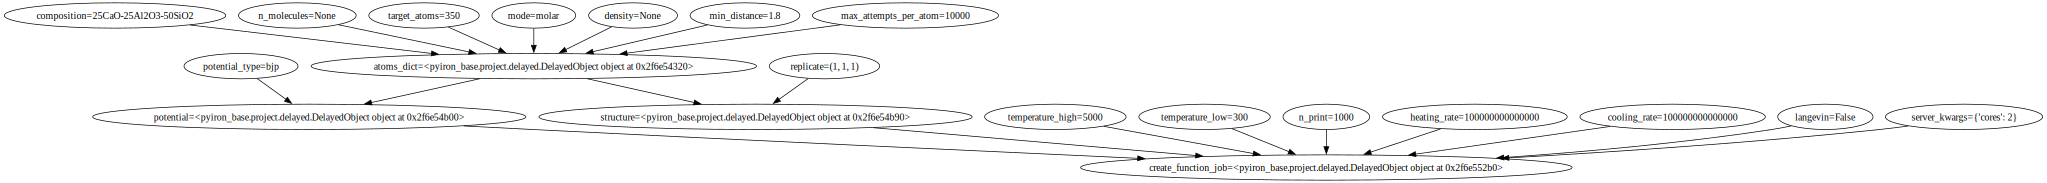

In [4]:
delayed.draw()

In [5]:
# Run the simulation and retrieve the results. Takes 5-10 minutes with the default testing parameters.
# result = delayed.pull()

In [6]:
# structure_glass = result["structure"]
# structure_glass

In [7]:
# Compute teh mean temperature of the last part of the simulation
# mean_temp = np.mean(result["result"]["temperature"])
# print(f"{mean_temp:.1f} K")

# Plot the temperature and the mean temperature
# plt.plot(result["result"]["steps"] * 1e-3, result["result"]["temperature"])
# plt.axhline(np.mean(result["result"]["temperature"]), color="red", linestyle="--")
# plt.xlabel("Time [ps]")
# plt.ylabel("Temperature [K]");

In [8]:
# from ase import units

# "# NBVAL_CHECK_OUTPUT"


# V = np.mean(result["result"]["volume"]) * 1e-24  # volume in cm#
# massTot = result["structure"].get_masses().sum() / units._Nav

# density = massTot / V
# print(f"{(massTot / V):.2f} g/cm3")